In [1]:
import pandas as pd
import numpy as np
import shap
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
import matplotlib.pyplot as plt
import scipy

# 日本語フォント設定 (グラフの文字化け防止)
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# ★設定: 学習済みモデルのパス
MODEL_PATH = "result_log_all/checkpoint-1500" 

# ★設定: 学習時に使用した元のモデル名 (トークナイザ用)
BASE_MODEL_NAME = "cl-tohoku/bert-base-japanese-whole-word-masking"
# ※ v3 で学習し直していたら "tohoku-nlp/bert-base-japanese-v3" に変更してください

# ★設定: SHAP分析する件数
# GPUを使ってもBERTのSHAP計算は重いです。まずは50件程度で動作確認してください。
NUM_SHAP_SAMPLES = 5000 
# ==========================================

print("設定完了。")

設定完了。


In [ ]:
# --- 1. データの読み込みと前処理 ---
corpus_path = 'dataset/narou_dataset.csv'

try:
    df = pd.read_csv(corpus_path)
    print("ファイルを読み込みました。")
except FileNotFoundError:
    print(f"エラー: ファイルが見つかりません - {corpus_path}")
    df = None

if df is not None:
    # テキストデータを結合
    df['あらすじ'] = df['あらすじ'].fillna('')
    df['text'] = df['あらすじ']

    # ラベルを定義
    df = df[['text', 'is_eternal']].rename(columns={'is_eternal': 'labels'})

    # バランスサンプリング
    df_eternal_0 = df[df['labels'] == 0]
    df_eternal_1 = df[df['labels'] == 1]
    n_samples = min(len(df_eternal_1), len(df_eternal_0))
    sampled_0 = df_eternal_0.sample(n=n_samples, random_state=42)
    df_balanced = pd.concat([sampled_0, df_eternal_1]).sample(frac=1, random_state=42).reset_index(drop=True)

    # テストデータの分割
    X_train, X_test, y_train, y_test = train_test_split(
        df_balanced['text'], df_balanced['labels'], test_size=0.2, random_state=42, stratify=df_balanced['labels']
    )
    
    print(f"データ準備完了。テストデータ数: {len(X_test)}件")

ファイルを読み込みました。
データ準備完了。テストデータ数: 58498件


In [3]:
# --- 2. 学習済みBERTモデルの読み込み (GPU設定) ---
print(f"\nモデルを読み込んでいます... Path: {MODEL_PATH}")

try:
    # GPUチェック
    if torch.cuda.is_available():
        device = 0 # GPU ID 0番を使用
        device_name = torch.cuda.get_device_name(0)
        print(f"★ GPUを使用します: {device_name}")
    else:
        device = -1 # CPUを使用
        print("※ GPUが見つかりません。CPUを使用します。")

    # モデル読み込み
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    # GPUへ転送
    if device == 0:
        model.to("cuda")
    
    # トークナイザ読み込み (元のモデル名から)
    print(f"トークナイザを {BASE_MODEL_NAME} からロードします...")
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

    # パイプラインの作成 (GPU使用設定)
    pipe = pipeline(
        "text-classification", 
        model=model, 
        tokenizer=tokenizer, 
        device=device, # ここでGPUを指定することで推論が高速化されます
        top_k=None,
        padding=True, 
        truncation=True,
        max_length=512
    )
    print("モデルの読み込み完了。")

except Exception as e:
    print(f"\n【エラー】モデルの読み込みに失敗しました。\n{e}")
    import traceback
    traceback.print_exc()
    pipe = None


モデルを読み込んでいます... Path: result_log_all/checkpoint-1500
★ GPUを使用します: NVIDIA GeForce RTX 3050
トークナイザを cl-tohoku/bert-base-japanese-whole-word-masking からロードします...


Device set to use cuda:0


モデルの読み込み完了。


In [ ]:
# --- 3. SHAPによる分析 (進捗バー付き・警告抑制版) ---
from tqdm.auto import tqdm
import transformers
import logging

# 警告メッセージ（Token indices sequence length...）を非表示にする設定
transformers.logging.set_verbosity_error()

if pipe is not None:
    print(f"\nSHAP分析を開始します（対象: {len(X_test)} 件中、先頭 {NUM_SHAP_SAMPLES} 件）...")
    print("※ 進捗バーが表示されます。")

    # SHAP Explainerの準備
    explainer = shap.Explainer(pipe)

    # 分析対象データの抽出
    X_test_subset = X_test.iloc[:NUM_SHAP_SAMPLES].tolist()

    # --- バッチ処理の設定 ---
    # 大量データを一度に渡すとメモリ不足やタイムアウトになるため、
    # 小分け（バッチ）にして計算し、進捗バーを表示します。
    BATCH_SIZE = 20 # 1回に計算する件数
    shap_values_list = [] # 結果を一時保存するリスト

    # tqdmを使って進捗バーを表示しながらループ
    # desc="分析中" でバーの左にタイトルを表示
    for i in tqdm(range(0, len(X_test_subset), BATCH_SIZE), desc="SHAP分析中"):
        batch_data = X_test_subset[i : i + BATCH_SIZE]
        
        # バッチごとにSHAP値を計算 (silent=TrueでSHAP標準のログを消す)
        batch_values = explainer(batch_data, silent=True)
        shap_values_list.append(batch_values)

    # --- 結果の結合 ---
    # 小分けにした結果を1つの SHAP Explanation オブジェクトに結合します
    print("結果を結合しています...")
    
    # テキスト用のSHAP値は構造が特殊なため、要素ごとに結合して再構築します
    shap_values = shap.Explanation(
        values=np.concatenate([x.values for x in shap_values_list], axis=0),
        base_values=np.concatenate([x.base_values for x in shap_values_list], axis=0),
        data=np.concatenate([x.data for x in shap_values_list], axis=0),
        feature_names=shap_values_list[0].feature_names
    )

    print("\nSHAP値の計算完了。")

else:
    print("パイプラインが作成されていないため、スキップします。")


SHAP分析を開始します（対象: 先頭 5000 件）...
※ GPUを使用していても、SHAP値の計算（順列計算）には時間がかかります。


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   0%|          | 3/5000 [00:17<2:32:06,  1.83s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|█████████▉| 4998/5000 [9:13:44<00:11,  5.80s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 5001it [9:13:58,  6.65s/it]                          



SHAP値の計算完了。



--- 全体的な重要語 (Top Words) ---


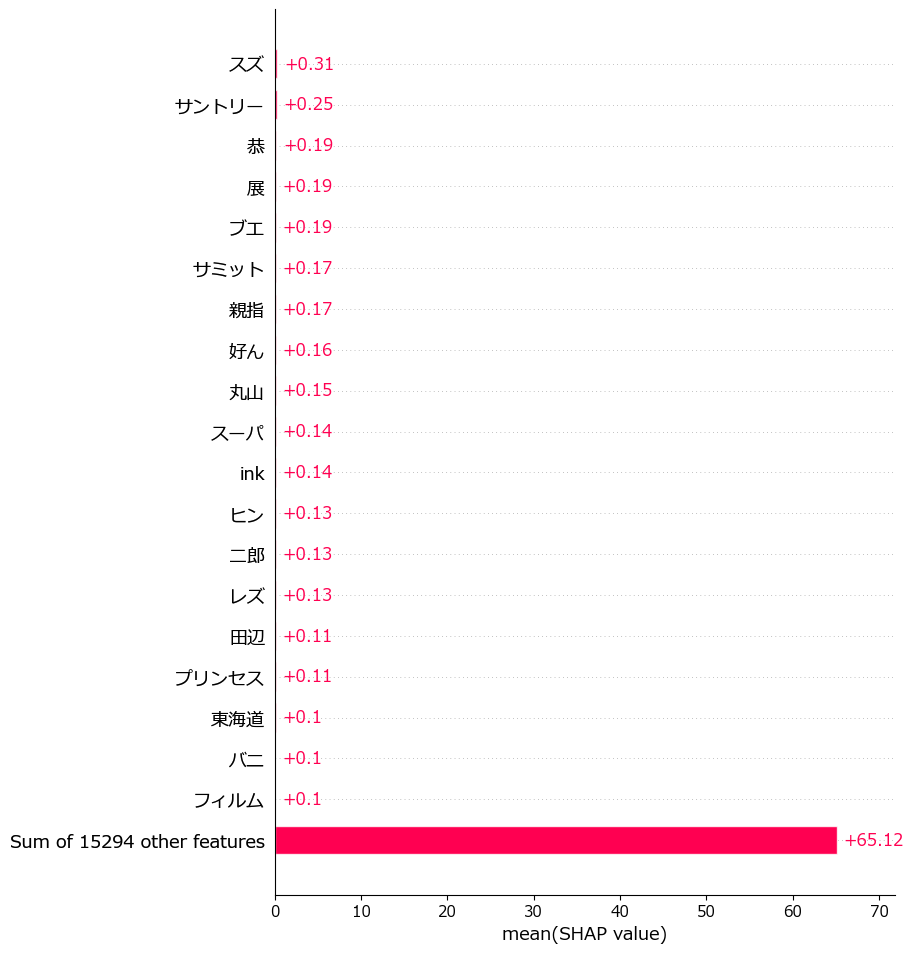


--- 個別データの分析例 (1件目) ---


In [5]:
# --- 4. 結果の可視化 ---
if 'shap_values' in locals():
    # (1) 全体的な重要語の可視化（Bar Plot）
    print(f"\n--- 全体的な重要語 (Top Words) ---")
    # クラス1（エタる）への寄与を表示
    # shap_values.shape -> (samples, tokens, classes)
    shap.plots.bar(shap_values[:, :, "LABEL_1"].mean(0), max_display=20)
    plt.show()

    # (2) 個別のテキストでの可視化（Text Plot）
    print(f"\n--- 個別データの分析例 (1件目) ---")
    shap.plots.text(shap_values[0, :, "LABEL_1"])
else:
    print("SHAP値が計算されていません。")